# Breast Cancer Classification

In [1]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from collections import Counter

In [2]:
# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [12]:
class BreaKHisDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.label_to_name = {}
        self.name_to_label = {}
        
        # Debug: Print the root directory being checked
        print(f"Checking dataset at: {os.path.abspath(root_dir)}")
        
        # First verify the directory structure exists
        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Root directory not found: {root_dir}")
        
        # Discover all disease classes
        self._discover_classes()
        
        # Collect all images if classes were found
        if self.label_to_name:
            self._collect_images()
        else:
            print("Warning: No disease classes found! Checking directory structure...")
            self._debug_directory_structure()
        
        print(f"\nFound {len(self.image_paths)} images across {len(self.label_to_name)} diseases:")
        for label, name in self.label_to_name.items():
            count = np.sum(np.array(self.labels) == label)
            print(f"- {name}: {count} images")

    def _discover_classes(self):
        """Discover all unique disease types in the dataset."""
        diseases = set()
        
        # Check both benign and malignant folders
        for class_type in ['benign', 'malignant']:
            class_dir = os.path.join(self.root_dir, class_type, "SOB")
            
            # Debug: Print the class directory being checked
            print(f"Checking {class_type} directory: {os.path.abspath(class_dir)}")
            
            if not os.path.exists(class_dir):
                print(f"Warning: {class_type} directory not found at {class_dir}")
                continue
                
            # Walk through the directory structure
            for root, dirs, files in os.walk(class_dir):
                # Typical structure: .../SOB_[class]_[disease]_[rest]/
                if 'SOB_' in root:
                    parts = root.split(os.sep)
                    try:
                        # Extract the disease name (e.g., "ductal_carcinoma")
                        disease_part = [p for p in parts if p.startswith('SOB_')][0]
                        disease = '_'.join(disease_part.split('_')[2:-1])
                        diseases.add(disease)
                    except IndexError:
                        continue
        
        # Create mappings if we found diseases
        if diseases:
            self.label_to_name = {i: name for i, name in enumerate(sorted(diseases))}
            self.name_to_label = {name: i for i, name in self.label_to_name.items()}
            print(f"Discovered disease classes: {list(self.label_to_name.values())}")

    def _collect_images(self):
        """Collect all images with their corresponding disease labels."""
        for class_type in ['benign', 'malignant']:
            class_dir = os.path.join(self.root_dir, class_type, "SOB")
            if not os.path.exists(class_dir):
                continue
                
            for root, dirs, files in os.walk(class_dir):
                for file in files:
                    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        try:
                            # Extract disease name from directory structure
                            disease_part = [p for p in root.split(os.sep) if p.startswith('SOB_')][0]
                            disease = '_'.join(disease_part.split('_')[2:-1])
                            
                            if disease in self.name_to_label:
                                img_path = os.path.join(root, file)
                                self.image_paths.append(img_path)
                                self.labels.append(self.name_to_label[disease])
                        except IndexError:
                            continue

    def _debug_directory_structure(self):
        """Print the directory structure to help debug issues."""
        print("\nDirectory structure debug:")
        for root, dirs, files in os.walk(self.root_dir):
            level = root.replace(self.root_dir, '').count(os.sep)
            indent = ' ' * 4 * level
            print(f"{indent}{os.path.basename(root)}/")
            if level > 3:  # Don't show files too deep
                continue
            for f in files[:3]:  # Show first 3 files
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    print(f"{indent}    {f}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [13]:
# Add this wrapper class after your dataset class definition
class AugmentWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

In [14]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [15]:
# Try multiple possible root directories
possible_roots = [
        r'C:\Users\LENOVO\Documents\Projects\Python\BreastTumorProject\BreaKHis_v1',
    ]

    # Modify your dataset loading section to use the wrapper:
    # Load dataset without transform initially
for root_dir in possible_roots:
    print(f"\nTrying dataset path: {root_dir}")
    try:
        full_dataset = BreaKHisDataset(root_dir=root_dir, transform=None)
        if len(full_dataset) > 0:
            print("Successfully loaded dataset!")
            break
    except Exception as e:
        print(f"Error with {root_dir}: {str(e)}")
else:
    raise FileNotFoundError("Could not find the dataset in any of the specified locations")


Trying dataset path: C:\Users\LENOVO\Documents\Projects\Python\BreastTumorProject\BreaKHis_v1
Checking dataset at: C:\Users\LENOVO\Documents\Projects\Python\BreastTumorProject\BreaKHis_v1
Checking benign directory: C:\Users\LENOVO\Documents\Projects\Python\BreastTumorProject\BreaKHis_v1\benign\SOB
Checking malignant directory: C:\Users\LENOVO\Documents\Projects\Python\BreastTumorProject\BreaKHis_v1\malignant\SOB
Discovered disease classes: ['A', 'DC', 'F', 'LC', 'MC', 'PC', 'PT', 'TA']

Found 7909 images across 8 diseases:
- A: 444 images
- DC: 3451 images
- F: 1014 images
- LC: 626 images
- MC: 792 images
- PC: 560 images
- PT: 453 images
- TA: 569 images
Successfully loaded dataset!


In [16]:
# Split dataset (keep your existing split)
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)


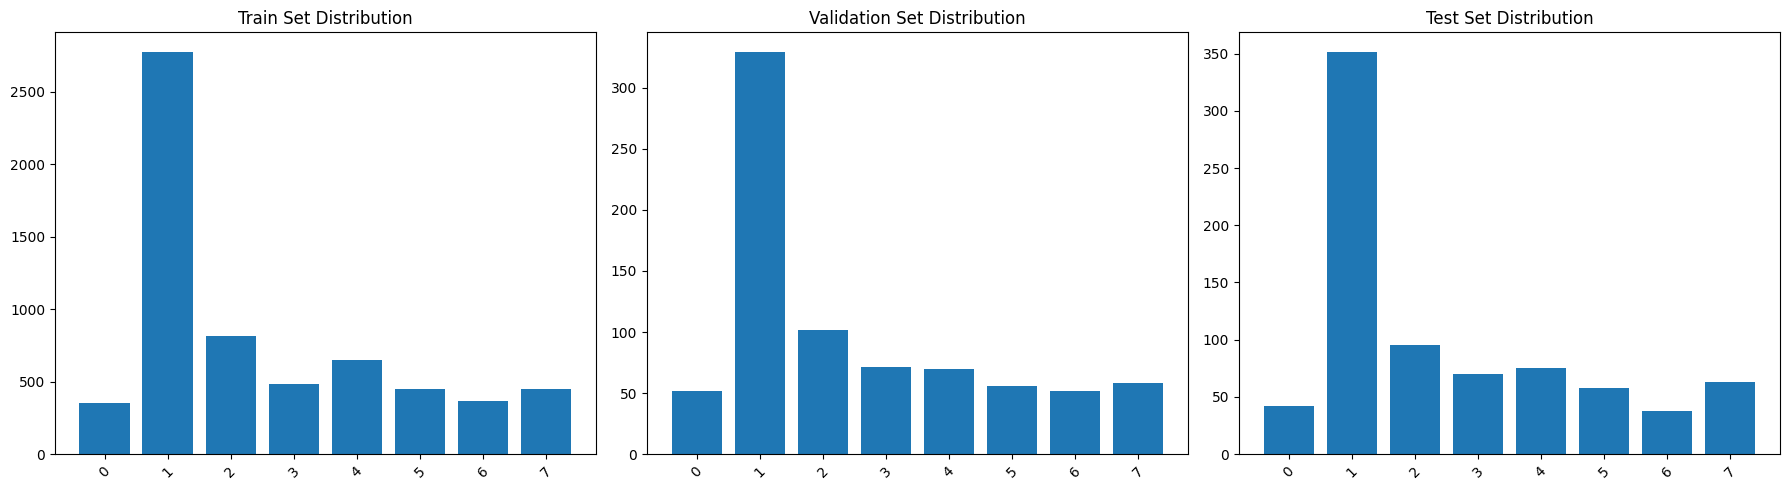


Split           Count      % of Total
-----------------------------------
Train           6327       80.0%     
  Class 0: 350 samples (5.5%)
  Class 1: 2771 samples (43.8%)
  Class 2: 817 samples (12.9%)
  Class 3: 485 samples (7.7%)
  Class 4: 647 samples (10.2%)
  Class 5: 446 samples (7.0%)
  Class 6: 363 samples (5.7%)
  Class 7: 448 samples (7.1%)
Validation      790        10.0%     
  Class 0: 52 samples (6.6%)
  Class 1: 329 samples (41.6%)
  Class 2: 102 samples (12.9%)
  Class 3: 71 samples (9.0%)
  Class 4: 70 samples (8.9%)
  Class 5: 56 samples (7.1%)
  Class 6: 52 samples (6.6%)
  Class 7: 58 samples (7.3%)
Test            792        10.0%     
  Class 0: 42 samples (5.3%)
  Class 1: 351 samples (44.3%)
  Class 2: 95 samples (12.0%)
  Class 3: 70 samples (8.8%)
  Class 4: 75 samples (9.5%)
  Class 5: 58 samples (7.3%)
  Class 6: 38 samples (4.8%)
  Class 7: 63 samples (8.0%)


In [17]:
# First, let's verify we can access labels without loading images
try:
    # Try accessing labels directly if they're stored separately
    if hasattr(full_dataset, 'labels'):
        train_labels = [full_dataset.labels[i] for i in train_subset.indices]
        val_labels = [full_dataset.labels[i] for i in val_subset.indices]
        test_labels = [full_dataset.labels[i] for i in test_subset.indices]
    else:
        # Alternative approach that doesn't load images
        train_labels = []
        for i in train_subset.indices:
            try:
                # Assuming your dataset returns (image, label) pairs
                train_labels.append(full_dataset[i][1])
            except:
                print(f"Couldn't access label for index {i}")
                continue
                
        val_labels = [full_dataset[i][1] for i in val_subset.indices]
        test_labels = [full_dataset[i][1] for i in test_subset.indices]
except Exception as e:
    print(f"Error accessing labels: {str(e)}")
    raise

# Get distributions
train_dist = Counter(train_labels)
val_dist = Counter(val_labels)
test_dist = Counter(test_labels)

# Plotting function
def plot_distribution(dist, title, ax):
    labels, counts = zip(*sorted(dist.items()))
    ax.bar([str(x) for x in labels], counts)
    ax.set_title(title)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45)

# Create plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
plot_distribution(train_dist, "Train Set Distribution", ax1)
plot_distribution(val_dist, "Validation Set Distribution", ax2)
plot_distribution(test_dist, "Test Set Distribution", ax3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\n{'Split':<15} {'Count':<10} {'% of Total':<10}")
print("-"*35)
for name, dist in [('Train', train_dist), ('Validation', val_dist), ('Test', test_dist)]:
    total = sum(dist.values())
    print(f"{name:<15} {total:<10} {total/len(full_dataset):<10.1%}")
    for label, count in sorted(dist.items()):
        print(f"  Class {label}: {count} samples ({count/total:.1%})")

Burada üç kısma ayırdığımız verinin etiketlerine göre dağılımı görünmektedir. Class 1'in yani DC etiketine sahip görsellerin büyük bir kısım kapladığı görülmektedir. Bu durum verisetinde imbalance durumu oluşturmaktadır. Bu durumu çözmeye çalışmayacağım çünkü aynı fazlalık durumu üç pakette de yaklaşık olarak benzerlik göstermektedir.

In [18]:
# Apply different transforms to each subset
train_dataset = AugmentWrapper(train_subset, transform=train_transform)
val_dataset = AugmentWrapper(val_subset, transform=val_test_transform)
test_dataset = AugmentWrapper(test_subset, transform=val_test_transform)

In [27]:
batch_size = 128
num_workers = 0 


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=False  # Disable for Windows compatibility
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=False
)

# Verify everything loaded correctly
print("\nVerifying data loading...")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Verifying data loading...
Train batches: 50
Val batches: 7
Test batches: 7


In [28]:
print("\nDataset successfully loaded with:")
print(f"- Training images: {len(train_subset)} (with augmentation)")
print(f"- Validation images: {len(val_subset)}")
print(f"- Test images: {len(test_subset)}")
print(f"- Disease classes: {list(full_dataset.label_to_name.values())}")


Dataset successfully loaded with:
- Training images: 6327 (with augmentation)
- Validation images: 790
- Test images: 792
- Disease classes: ['A', 'DC', 'F', 'LC', 'MC', 'PC', 'PT', 'TA']


In [29]:
def visualize_augmentations(dataset, num_samples=5, cols=5):
    # Get sample images
    samples = [dataset[i][0] for i in range(num_samples)]
    
    # Create figure
    plt.figure(figsize=(15, 5))
    
    for i in range(num_samples):
        # Denormalize image
        img = samples[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Plot original
        plt.subplot(1, cols, i+1)
        plt.imshow(img)
        plt.axis('off')
        if i == 0:
            plt.title("Original")
    
    plt.tight_layout()
    plt.show()

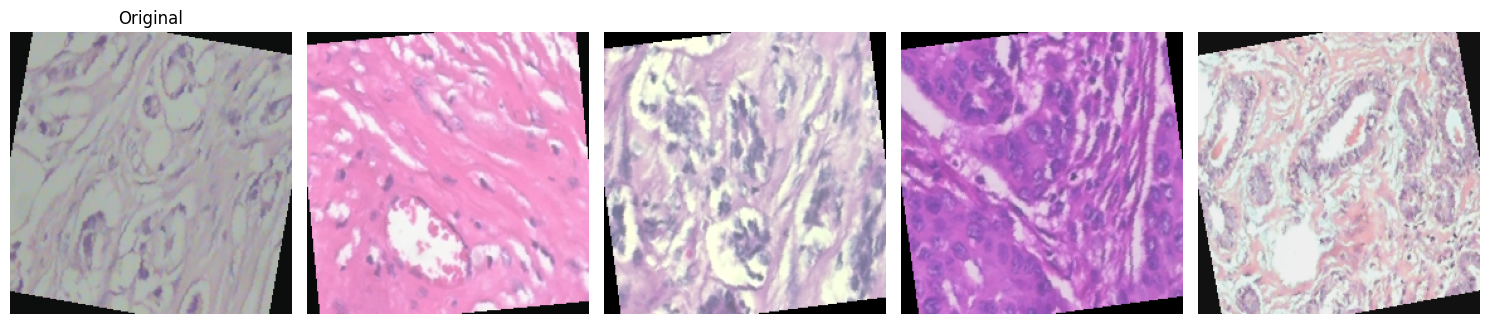

In [30]:
# Usage (add this to your main() function):
visualize_augmentations(train_dataset, num_samples=5)

Training aşamasında veir beslemesi yaparken görseller rastgele şekilde döndürelecektir. Bu sayede modelin farklı açıları da görerek daha sağlıklı bir şekilde eğitilmesi sağlanacaktır.

## Training

In [31]:
torch.cuda.empty_cache()

In [33]:
# After your data augmentation code...

assert torch.cuda.is_available(), "CUDA not available!"
device = torch.device("cuda:0")
print(f"\nCUDA Device: {torch.cuda.get_device_name(0)}")
print(f"Memory - Allocated: {torch.cuda.memory_allocated()/1024**2:.2f}MB | "
      f"Cached: {torch.cuda.memory_reserved()/1024**2:.2f}MB\n")

# 2. Load pretrained model with transfer learning
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last two layers for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True

# Enhanced model head
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.GELU(),  # Better than ReLU
    nn.Dropout(0.5),  # Increased dropout
    nn.Linear(512, 256),
    nn.LayerNorm(256),  # Better for small batches
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(256, len(full_dataset.label_to_name)),
    nn.Softmax(dim=1) 
    )

# Initialize gradient scaler for mixed precision training
scaler = torch.cuda.amp.GradScaler()

# Verify model is on GPU
model = model.to(device)
print(f"Model device: {next(model.parameters()).device}")
print(f"First batch device check: {next(iter(train_loader))[0].device}")

# 3. Enhanced training loop with debugging
def train_model(model, train_loader, val_loader, epochs=15):

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': []
    }

    # Optimizer with differential learning rates
    optimizer = optim.AdamW([
        {'params': model.fc.parameters(), 'lr': 3e-4},  # Higher for new head
        {'params': model.layer4.parameters(), 'lr': 1e-4},
        {'params': model.layer3.parameters(), 'lr': 3e-5}],
        weight_decay=1e-4, eps=1e-8
    )  # Added epsilon for numerical stability

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[3e-4, 1e-4, 3e-5],  # Matches optimizer groups
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.3,  # Longer warmup
        div_factor=10,  # Start 10x lower than max
        final_div_factor=100  # End 100x lower than max
    )
    
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 50)
        
        # Training Phase
        model.train()
        train_loss = 0.0
        
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            # Transfer to GPU with verification
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            assert inputs.device.type == 'cuda', "Inputs not on GPU!"
            assert labels.device.type == 'cuda', "Labels not on GPU!"
            
            optimizer.zero_grad(set_to_none=True)
            
            # Mixed precision forward pass
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            # Scaled backward pass
            scaler.scale(loss).backward()
            
            # Gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            
            train_loss += loss.item()
            
            # Print progress every 5 batches
            if batch_idx % 5 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                current_samples = batch_idx * train_loader.batch_size
                total_samples = len(train_loader.dataset)
                progress = 100. * batch_idx / len(train_loader)
                print(f"Train: {current_samples}/{total_samples} ({progress:.1f}%) | "
                      f"Loss: {loss.item():.4f} | LR: {current_lr:.2e}")
                
                # GPU memory monitoring
                if device.type == 'cuda':
                    print(f"GPU Mem: {torch.cuda.memory_allocated()/1024**2:.1f}MB", end='\r')
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        correct = 0
        
        with torch.no_grad():
            for batch_idx, (inputs, labels) in enumerate(val_loader):
                inputs, labels = inputs.to(device), labels.to(device)
                
                # Forward pass with autocast for consistency
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                
                if batch_idx % 3 == 0:
                    print(f"Val: Batch {batch_idx}/{len(val_loader)}")
        

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / len(val_loader.dataset)
        
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        
        # Calculate metrics
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        val_acc = correct / len(val_loader.dataset)
        
        print(f"\nEpoch {epoch+1} Results:")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Val Accuracy: {val_acc:.4f}")
        
        # Force CUDA sync and clear cache
        if device.type == 'cuda':
            torch.cuda.synchronize()
            torch.cuda.empty_cache()

if __name__=="__main__":
    # Clear GPU cache before training
    torch.cuda.empty_cache()
    
    # Start training with error handling
    try:
        print("\nStarting training...")
        train_model(model, train_loader, val_loader, epochs=50)
    except Exception as e:
        print(f"\nTraining failed: {str(e)}")
        if device.type == 'cuda':
            print("CUDA Status:")
            print(f"Memory allocated: {torch.cuda.memory_allocated()/1024**2:.2f}MB")
            print(f"Memory cached: {torch.cuda.memory_reserved()/1024**2:.2f}MB")
            print(f"CUDA last error: {torch.cuda.get_last_error()}")
        raise


CUDA Device: NVIDIA GeForce RTX 4050 Laptop GPU
Memory - Allocated: 848.09MB | Cached: 2508.00MB



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8444\767041258.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Model device: cuda:0
First batch device check: cpu

Starting training...

Epoch 1/50
--------------------------------------------------


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8444\767041258.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train: 0/6327 (0.0%) | Loss: 2.0834 | LR: 3.00e-05
Train: 640/6327 (10.0%) | Loss: 2.0839 | LR: 3.00e-05
Train: 1280/6327 (20.0%) | Loss: 2.0654 | LR: 3.01e-05
Train: 1920/6327 (30.0%) | Loss: 2.0657 | LR: 3.03e-05
Train: 2560/6327 (40.0%) | Loss: 2.0538 | LR: 3.05e-05
Train: 3200/6327 (50.0%) | Loss: 2.0456 | LR: 3.08e-05
Train: 3840/6327 (60.0%) | Loss: 2.0359 | LR: 3.11e-05
Train: 4480/6327 (70.0%) | Loss: 2.0128 | LR: 3.15e-05
Train: 5120/6327 (80.0%) | Loss: 2.0001 | LR: 3.20e-05
Train: 5760/6327 (90.0%) | Loss: 1.9856 | LR: 3.25e-05


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8444\767041258.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Val: Batch 0/7
Val: Batch 3/7
Val: Batch 6/7

Epoch 1 Results:
Train Loss: 2.0393 | Val Loss: 1.9522
Val Accuracy: 0.4241

Epoch 2/50
--------------------------------------------------
Train: 0/6327 (0.0%) | Loss: 1.9749 | LR: 3.31e-05
Train: 640/6327 (10.0%) | Loss: 1.9573 | LR: 3.37e-05
Train: 1280/6327 (20.0%) | Loss: 1.9312 | LR: 3.44e-05
Train: 1920/6327 (30.0%) | Loss: 1.9134 | LR: 3.51e-05
Train: 2560/6327 (40.0%) | Loss: 1.9116 | LR: 3.59e-05
Train: 3200/6327 (50.0%) | Loss: 1.9193 | LR: 3.68e-05
Train: 3840/6327 (60.0%) | Loss: 1.9066 | LR: 3.77e-05
Train: 4480/6327 (70.0%) | Loss: 1.9130 | LR: 3.87e-05
Train: 5120/6327 (80.0%) | Loss: 1.8983 | LR: 3.97e-05
Train: 5760/6327 (90.0%) | Loss: 1.8722 | LR: 4.08e-05
Val: Batch 0/76MB
Val: Batch 3/7
Val: Batch 6/7

Epoch 2 Results:
Train Loss: 1.9144 | Val Loss: 1.8581
Val Accuracy: 0.4418

Epoch 3/50
--------------------------------------------------
Train: 0/6327 (0.0%) | Loss: 1.8462 | LR: 4.19e-05
Train: 640/6327 (10.0%) | Loss:

KeyboardInterrupt: 

Burada early stopping yaptım. Bunu yapmamın sebebi ise train loss'un düşerken validation loss'un yükselmesi oldu. Yani modelin overfit olmasını engellemek için durdurdum.

## Model Evaluation

In [37]:
def evaluate_test_set(model, test_loader):
    model.eval()
    model.fc.train_mode = False  # Ensure softmax is applied
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    # Generate confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=full_dataset.label_to_name.values(),
                yticklabels=full_dataset.label_to_name.values())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    return all_preds, all_targets

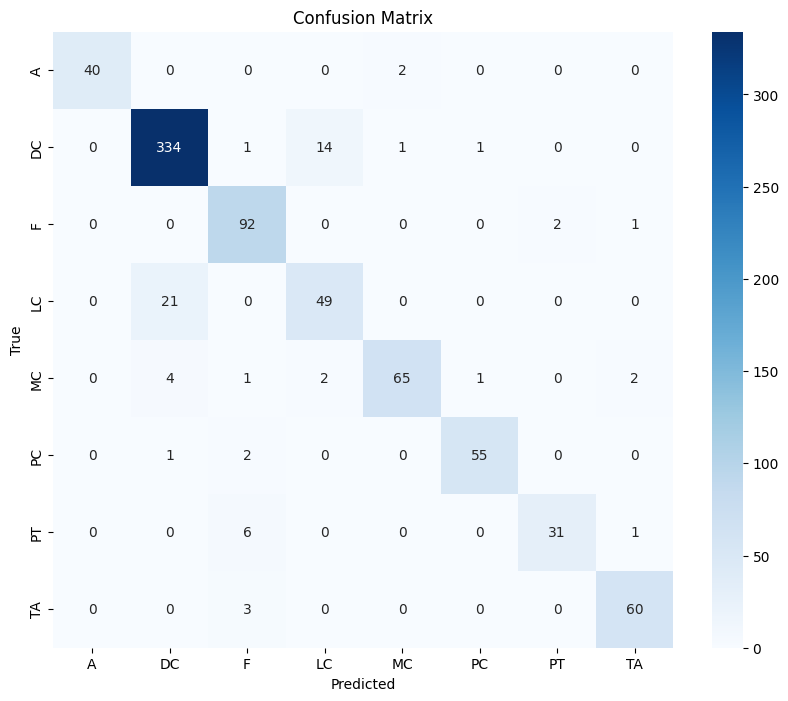


Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.95      0.98        42
          DC       0.93      0.95      0.94       351
           F       0.88      0.97      0.92        95
          LC       0.75      0.70      0.73        70
          MC       0.96      0.87      0.91        75
          PC       0.96      0.95      0.96        58
          PT       0.94      0.82      0.87        38
          TA       0.94      0.95      0.94        63

    accuracy                           0.92       792
   macro avg       0.92      0.89      0.91       792
weighted avg       0.92      0.92      0.92       792



In [38]:
def print_classification_report(test_loader):
    test_preds, test_targets = evaluate_test_set(model, test_loader)
    
    print("\nClassification Report:")
    print(classification_report(test_targets, test_preds, 
                               target_names=full_dataset.label_to_name.values()))

# Usage
print_classification_report(test_loader)

Bu modelde bir öncekine göre daha yüksek performans görülmektedir. Aynı zamanda eğitim imbalance sorunu bir önceki modele göre daha düşük görünmektedir. Bu modelin bir öncekinde farkı learning rate parametresiydi.